# MNIST From Scratch

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Data

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

## 3. X and y 

In [3]:
X = mnist.data
y = mnist.target.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


## 4. See the first digit

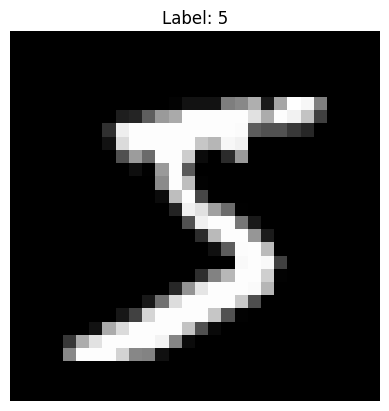

In [4]:
plt.imshow(X[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

## 5. Normalise the data
 Before normalise we have a pixel between 1-255 after normalise it will reduce to 0-1.
 NN works better on scaled data

In [5]:
print("Minimum:", X.min())
print("Maximum:", X.max())
X = X / 255.0
print("Minimum after normalise:", X.min())   #0.0
print("Maximum after normalise:", X.max())   #1.0

Minimum: 0
Maximum: 255
Minimum after normalise: 0.0
Maximum after normalise: 1.0


## 6. Build our First Neuron

### 6.1 Create a Simple neuron

In [6]:
x = X[0] 
print("x shape:", x.shape)
w = np.random.randn(784)
b = 0.0
z = np.dot(w, x) + b
print("z =", z)

x shape: (784,)
z = -5.686837153910659


### 6.2 Add ReLU 

In [7]:
def relu(z):
    return np.maximum(0, z)

a = relu(z)
print("After ReLU:", a)


After ReLU: 0.0


## 7. Make a Layer

In [8]:
weights = np.random.randn(784, 128) * 0.01
biases = np.zeros(128)

z = np.dot(X[:5], weights) + biases
print("Shape:", z.shape)

a = relu(z)
print("a_shape:", a.shape)

Shape: (5, 128)
a_shape: (5, 128)


## 8. Add the Output layer

### 8.1 Create w and b for output layer

In [9]:
output_w = np.random.randn(128, 10) * 0.01
output_b = np.zeros(10)

### 8.2 Calculate Output Layer

In [10]:
hidden_a = relu(z)
output_z = np.dot(hidden_a, output_w) + output_b
print("output_z:", output_z.shape)

output_z: (5, 10)


## 9. Softmax

In [11]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

probabilities = softmax(output_z)

print("Probabilities Shape:", probabilities.shape)
print("\nValues: ", probabilities[0])
print("\nSum:", np.sum(probabilities[0]))

predictions = np.argmax(probabilities, axis=1)

print("Predictions:",predictions)

Probabilities Shape: (5, 10)

Values:  [0.10035223 0.09994244 0.1000687  0.10030609 0.10127235 0.09833001
 0.09944191 0.09979084 0.09986055 0.10063487]

Sum: 1.0
Predictions: [4 3 8 3 3]


## 10. Cross-Entropy Loss

In [12]:
def cross_entropy_loss(probabilities, y):
    m = y.shape[0]
    
    correct_probability = probabilities[np.arange(m), y]
    loss = -np.log(correct_probability)
    return np.mean(loss)

loss = cross_entropy_loss(probabilities, y[:5])

print("Actual labels:", y[:5])
print("Predictions:", predictions)
print("Loss:", loss)

Actual labels: [5 0 4 1 9]
Predictions: [4 3 8 3 3]
Loss: 2.3041492939818484


## 11. Backpropogation

### 11.1 Create one-hot labels

In [13]:
y_batch = y[:5]
y_one_hot = np.zeros((5, 10))
y_one_hot[np.arange(5), y_batch] = 1
print("One Hot Labels:\n", y_one_hot)

One Hot Labels:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


### 11.2 Calculate Output Gradient

In [14]:
d_output = probabilities - y_one_hot
print("d_output:", d_output.shape)

d_output: (5, 10)


## 12. Gradient of Output weights

In [15]:
m = 5

d_output_weights = np.dot(hidden_a.T, d_output) / m
d_output_biases = np.sum(d_output, axis=0, keepdims=True) / m

print("d_output_weights:", d_output_weights.shape)
print("d_output_biases:", d_output_biases.shape)

d_output_weights: (128, 10)
d_output_biases: (1, 10)


## 13. Update the output w and b

In [16]:
learning_rate = 0.1

In [17]:
output_w -= learning_rate * d_output_weights
output_b -= learning_rate * d_output_biases.flatten()

## 14. Backpropogate through

### 14.1 output layer

In [18]:
d_hidden = np.dot(d_output, output_w.T)     #type:ignore
print("d_hidden:", d_hidden.shape)

d_hidden: (5, 128)


### 14.2 ReLU

In [19]:
d_z_hidden = d_hidden * (z>0)
print("d_z_hidden:", d_z_hidden.shape)

d_z_hidden: (5, 128)


## 15. Gradient of Hidden weights

In [20]:
d_weights = np.dot(X[:5].T, d_z_hidden) / 5
d_biases = np.sum(d_z_hidden, axis=0, keepdims=True) / 5
print("d_weights:", d_weights.shape)
print("d_biases:", d_biases.shape)

d_weights: (784, 128)
d_biases: (1, 128)


## 16. Update the hidden layer

In [21]:
weights -= learning_rate * d_weights
biases -= learning_rate * d_biases.flatten()

## 17. Training Loop

### 17.1 Divide Train - Test

In [22]:
X_train = X[:60000]
X_test = X[60000:]
y_train = y[:60000]
y_test = y[60000:]

### 17.2 Reinitialise the network

In [23]:
np.random.seed(42)

weights = np.random.randn(784, 128) * 0.01
biases = np.zeros(128)

output_weights = np.random.randn(128, 10) * 0.01
output_biases = np.zeros(10)

### 17.3 Set training parameters

In [24]:
learning_rate = 0.1
batch_size = 64
epochs = 10

### 17.4 Training loop

In [25]:
for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    X_train = X_train[indices]
    y_train = y_train[indices]

    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train[start:end]
        y_batch = y_train[start:end]

        # --------------------
        # FORWARD PASS
        # --------------------

        z_hidden = np.dot(X_batch, weights) + biases
        hidden_output = relu(z_hidden)

        z_output = np.dot(hidden_output, output_weights) + output_biases
        probabilities = softmax(z_output)

        # --------------------
        # LOSS
        # --------------------

        loss = cross_entropy_loss(probabilities, y_batch)

        # --------------------
        # BACKPROPAGATION
        # --------------------

        m = len(X_batch)

        # Output gradient
        y_one_hot = np.zeros((m, 10))
        y_one_hot[np.arange(m), y_batch] = 1

        d_output = probabilities - y_one_hot

        # Output layer gradients
        d_output_weights = np.dot(
            hidden_output.T,
            d_output
        ) / m

        d_output_biases = np.sum(
            d_output,
            axis=0,
            keepdims=True
        ) / m

        # Hidden layer gradient
        d_hidden = np.dot(
            d_output,
            output_weights.T
        )

        # ReLU gradient
        d_z_hidden = d_hidden * (z_hidden > 0)

        # Hidden layer gradients
        d_weights = np.dot(
            X_batch.T,
            d_z_hidden
        ) / m

        d_biases = np.sum(
            d_z_hidden,
            axis=0,
            keepdims=True
        ) / m

        # --------------------
        # UPDATE WEIGHTS
        # --------------------

        weights -= learning_rate * d_weights
        biases -= learning_rate * d_biases.flatten()

        output_weights -= learning_rate * d_output_weights
        output_biases -= learning_rate * d_output_biases.flatten()

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {loss:.4f}"
    )

Epoch 1/10, Loss: 0.4582
Epoch 2/10, Loss: 0.3671
Epoch 3/10, Loss: 0.2654
Epoch 4/10, Loss: 0.1577
Epoch 5/10, Loss: 0.0085
Epoch 6/10, Loss: 0.1140
Epoch 7/10, Loss: 0.0512
Epoch 8/10, Loss: 0.0138
Epoch 9/10, Loss: 0.1912
Epoch 10/10, Loss: 0.0852


## 18. Test the network

In [26]:
# Forward pass on test data

z_hidden_test = np.dot(X_test, weights) + biases    #type:ignore
hidden_test = relu(z_hidden_test)

z_output_test = np.dot(
    hidden_test,
    output_weights     #type:ignore
) + output_biases      #type:ignore

probabilities_test = softmax(z_output_test)

predictions_test = np.argmax(
    probabilities_test,
    axis=1
)

accuracy = np.mean(
    predictions_test == y_test
)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 0.975
Test Accuracy (%): 97.5


## 19. Visualize Predictions

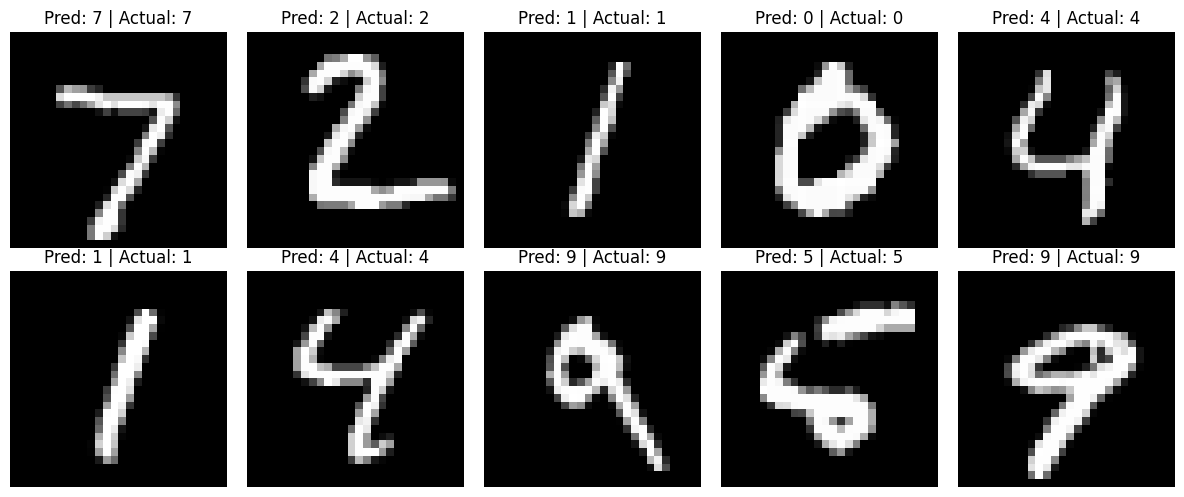

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    
    ax.set_title(
        f"Pred: {predictions_test[i]} | "
        f"Actual: {y_test[i]}"
    )
    
    ax.axis("off")

plt.tight_layout()
plt.show()

## 20. Wrong Prediction

In [28]:
wrong_indices = np.where(
    predictions_test != y_test
)[0]

print("Total wrong predictions:", len(wrong_indices))

Total wrong predictions: 250


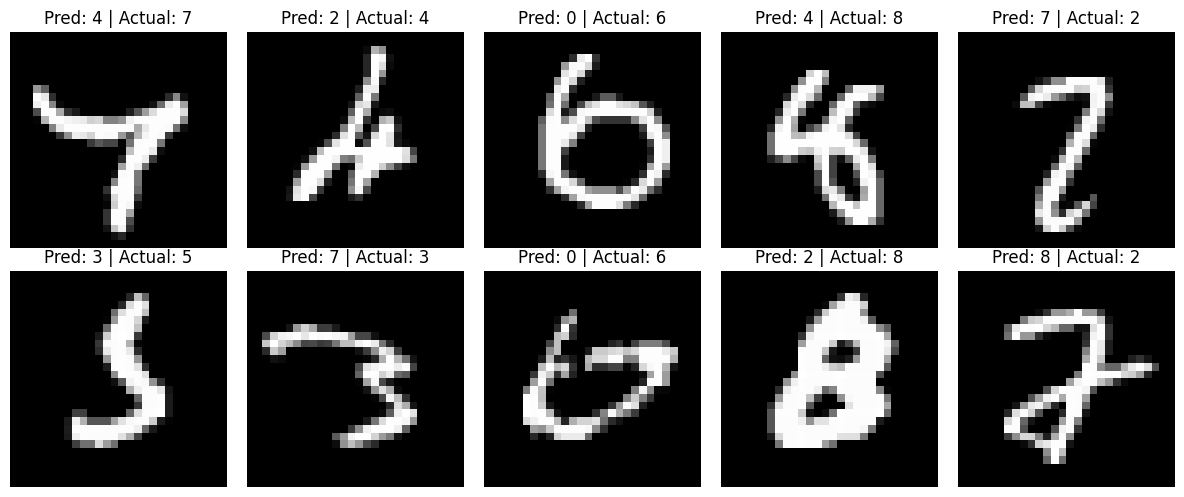

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    index = wrong_indices[i]

    ax.imshow(
        X_test[index].reshape(28, 28),
        cmap="gray"
    )

    ax.set_title(
        f"Pred: {predictions_test[index]} | "
        f"Actual: {y_test[index]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()